# 11 — Visual Cross-Domain Check on CarDD

## Purpose

This notebook performs a simple visual check of the final vehicle-part segmentation model on damaged-car images selected manually from CarDD.

It does **not** train or tune the model. It does not calculate accuracy because CarDD does not provide matching ground-truth annotations for the vehicle-part classes. The original image and prediction are displayed side by side for manual inspection.

## What We Will Do

1. Verify the Kaggle GPU.
2. locate the uploaded model weights and CarDD dataset.
3. Choose CarDD images manually.
4. Run the model on those images.
5. Compare the original images with the predicted masks.
6. Save the prediction images and document the findings.

Select normal-distance, close-up, heavily damaged, angled, and cropped images. Close-up images are especially important because the initial inspection suggests that the model struggles when the camera is very close to the vehicle.

## 1. Setup

In [3]:
%pip install -q ultralytics==8.4.138

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [5]:
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU is not available. Enable GPU in Kaggle Notebook Settings."
    )

DEVICE = 0
print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Kaggle Inputs

Add two inputs to the notebook:

1. CarDD dataset.
2. `carparts_yolo11n_wheel_fixed_v3_best.pt`.

The model is located automatically by its exact filename. Set `CARDD_DIR` to the CarDD folder shown in the Kaggle Input panel.

In [6]:
MODEL_FILENAME = "carparts_yolo11n_wheel_fixed_v3_best.pt"
model_candidates = list(Path("/kaggle/input").rglob(MODEL_FILENAME))

if len(model_candidates) != 1:
    raise FileNotFoundError(
        f"Expected exactly one {MODEL_FILENAME}, found "
        f"{len(model_candidates)}: {model_candidates}"
    )

MODEL_PATH = model_candidates[0]

CARDD_DIR = Path(
    "/kaggle/input/datasets/haifafd/cardd-dataset/"
    "CarDD_release/CarDD_COCO"
)
OUTPUT_DIR = Path("/kaggle/working/cardd_part_visual_check")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Model:", MODEL_PATH)
print("CarDD:", CARDD_DIR)
print("Outputs:", OUTPUT_DIR)

Model: /kaggle/input/models/haifafd/carparts-yolo11n-wheel-fixed-v3/pytorch/-/1/carparts_yolo11n_wheel_fixed_v3_best.pt
CarDD: /kaggle/input/datasets/haifafd/cardd-dataset/CarDD_release/CarDD_COCO
Outputs: /kaggle/working/cardd_part_visual_check


In [7]:
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model not found: {MODEL_PATH}")

if not CARDD_DIR.exists():
    raise FileNotFoundError(
        "CarDD folder not found. Copy its path from the Kaggle Input panel "
        "and update CARDD_DIR in the previous cell."
    )

print("Input paths are correct.")

Input paths are correct.


## 3. Load the Final Vehicle-Part Model

In [8]:
model = YOLO(str(MODEL_PATH))

print("Device:", DEVICE)
print("Model classes:", model.names)

Device: 0
Model classes: {0: 'back_bumper', 1: 'back_door', 2: 'back_glass', 3: 'back_light', 4: 'front_bumper', 5: 'front_door', 6: 'front_glass', 7: 'front_light', 8: 'hood', 9: 'side_mirror', 10: 'trunk_or_tailgate', 11: 'truck_bed', 12: 'wheel'}


## 4. View Available CarDD Image Paths

This cell lists example paths. You can also expand the CarDD folders in the Kaggle Input panel and copy the paths of images you want to inspect.

In [9]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

all_images = sorted([
    path for path in CARDD_DIR.rglob("*")
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
])

if not all_images:
    raise FileNotFoundError(f"No images found under: {CARDD_DIR}")

print("Total images found:", len(all_images))
print("\nFirst 30 relative paths:\n")

for image_path in all_images[:30]:
    print(image_path.relative_to(CARDD_DIR))

Total images found: 4000

First 30 relative paths:

test2017/000012.jpg
test2017/000015.jpg
test2017/000023.jpg
test2017/000033.jpg
test2017/000040.jpg
test2017/000042.jpg
test2017/000044.jpg
test2017/000057.jpg
test2017/000082.jpg
test2017/000088.jpg
test2017/000090.jpg
test2017/000106.jpg
test2017/000128.jpg
test2017/000152.jpg
test2017/000165.jpg
test2017/000175.jpg
test2017/000185.jpg
test2017/000191.jpg
test2017/000204.jpg
test2017/000214.jpg
test2017/000224.jpg
test2017/000233.jpg
test2017/000237.jpg
test2017/000253.jpg
test2017/000267.jpg
test2017/000288.jpg
test2017/000293.jpg
test2017/000297.jpg
test2017/000310.jpg
test2017/000320.jpg


## 5. Select Images Manually

Replace the examples with paths you choose. Use approximately 8–12 images and include both easy and difficult cases.

In [28]:
SELECTED_IMAGES = [
    CARDD_DIR / "test2017" / "000204.jpg",
    CARDD_DIR / "test2017" / "000404.jpg",
    CARDD_DIR / "test2017" / "000603.jpg",
    CARDD_DIR / "test2017" / "000237.jpg",
    CARDD_DIR / "test2017" / "003959.jpg",
]

if not SELECTED_IMAGES:
    raise ValueError(
        "Add the CarDD images you want to inspect to SELECTED_IMAGES."
    )

missing_images = [path for path in SELECTED_IMAGES if not path.exists()]
if missing_images:
    raise FileNotFoundError(f"Selected images not found: {missing_images}")

print("Selected images:", len(SELECTED_IMAGES))
for image_path in SELECTED_IMAGES:
    print("-", image_path.relative_to(CARDD_DIR))

Selected images: 5
- test2017/000204.jpg
- test2017/000404.jpg
- test2017/000603.jpg
- test2017/000237.jpg
- test2017/003959.jpg


## 6. Display the Original Images

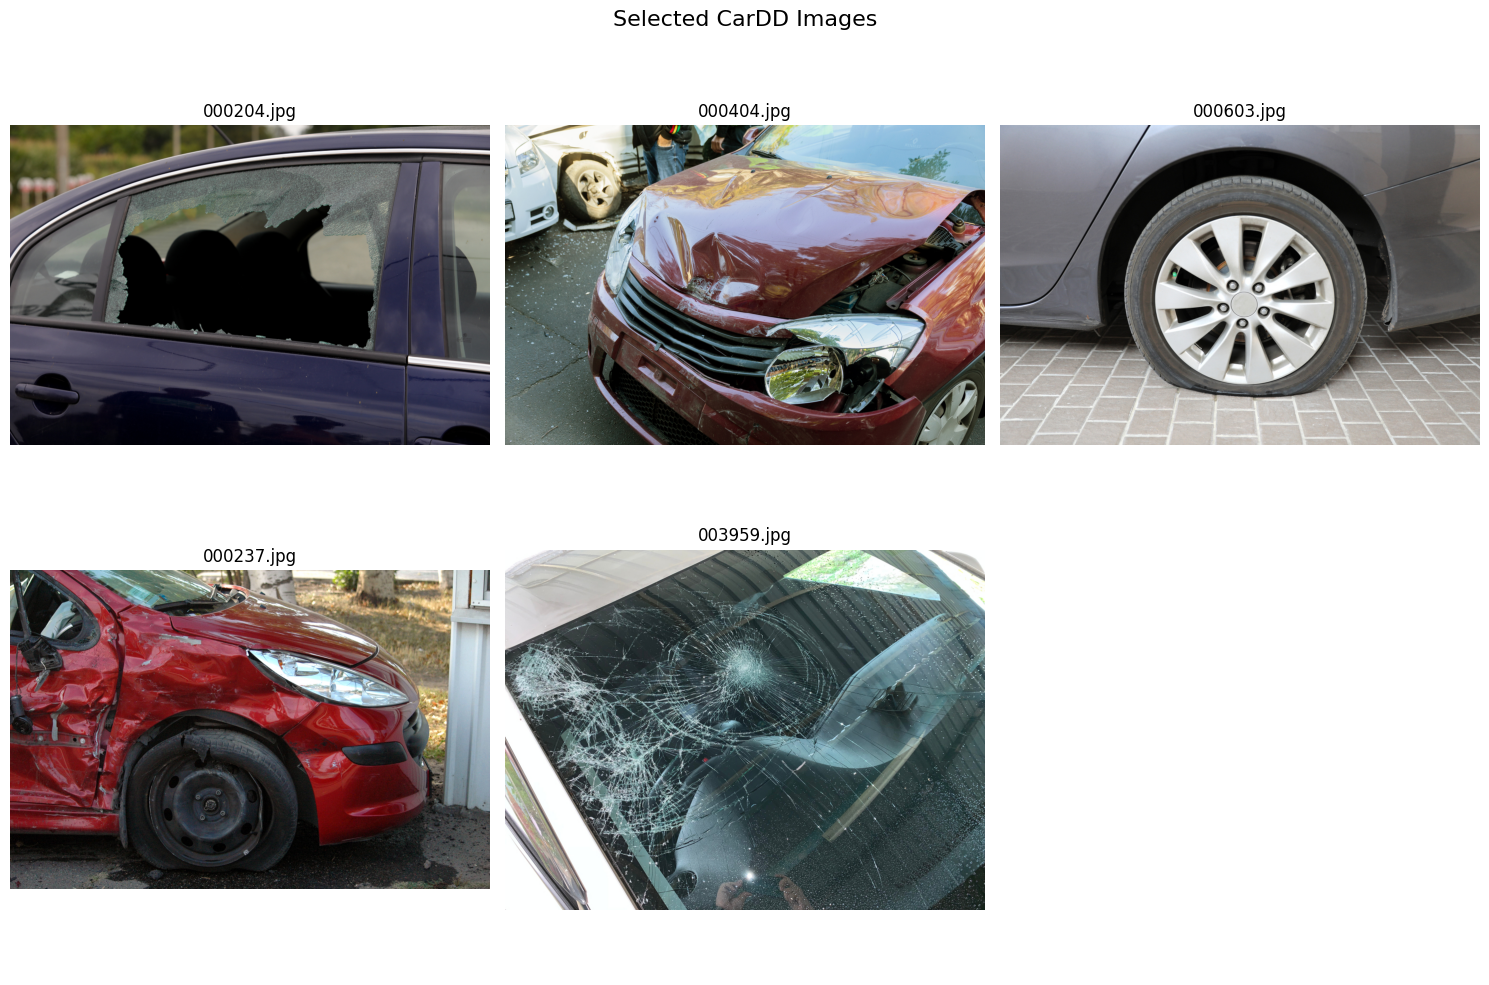

In [29]:
columns = 3
rows = int(np.ceil(len(SELECTED_IMAGES) / columns))

fig, axes = plt.subplots(rows, columns, figsize=(15, 5 * rows))
axes = np.atleast_1d(axes).ravel()

for axis, image_path in zip(axes, SELECTED_IMAGES):
    with Image.open(image_path) as image:
        axis.imshow(image.convert("RGB"))
    axis.set_title(image_path.name)
    axis.axis("off")

for axis in axes[len(SELECTED_IMAGES):]:
    axis.axis("off")

plt.suptitle("Selected CarDD Images", fontsize=16)
plt.tight_layout()
plt.show()

## 7. Run Inference on GPU

The same inference settings are used for every selected image. Do not change the confidence threshold separately for individual images.

In [30]:
results = model.predict(
    source=[str(path) for path in SELECTED_IMAGES],
    imgsz=640,
    conf=0.25,
    iou=0.70,
    device=DEVICE,
    batch=8,
    retina_masks=True,
    save=False,
    verbose=False,
)

print("Completed predictions:", len(results))

Completed predictions: 5


## 8. Compare Original Images with Predictions

Each row shows the original image on the left and the predicted vehicle-part masks on the right.

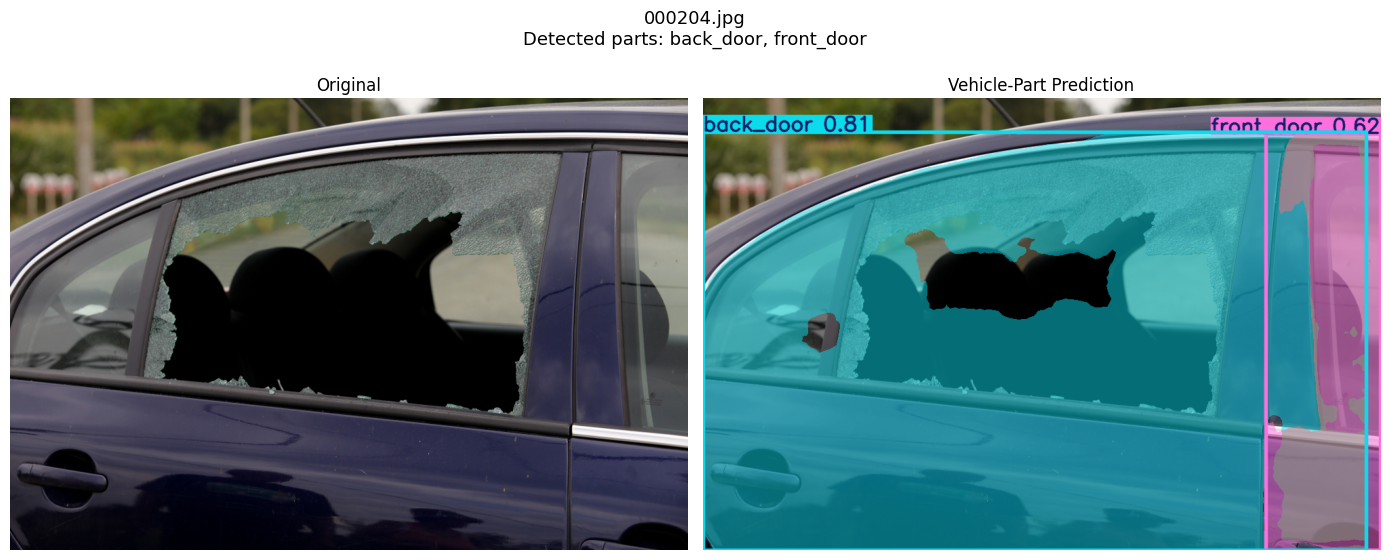

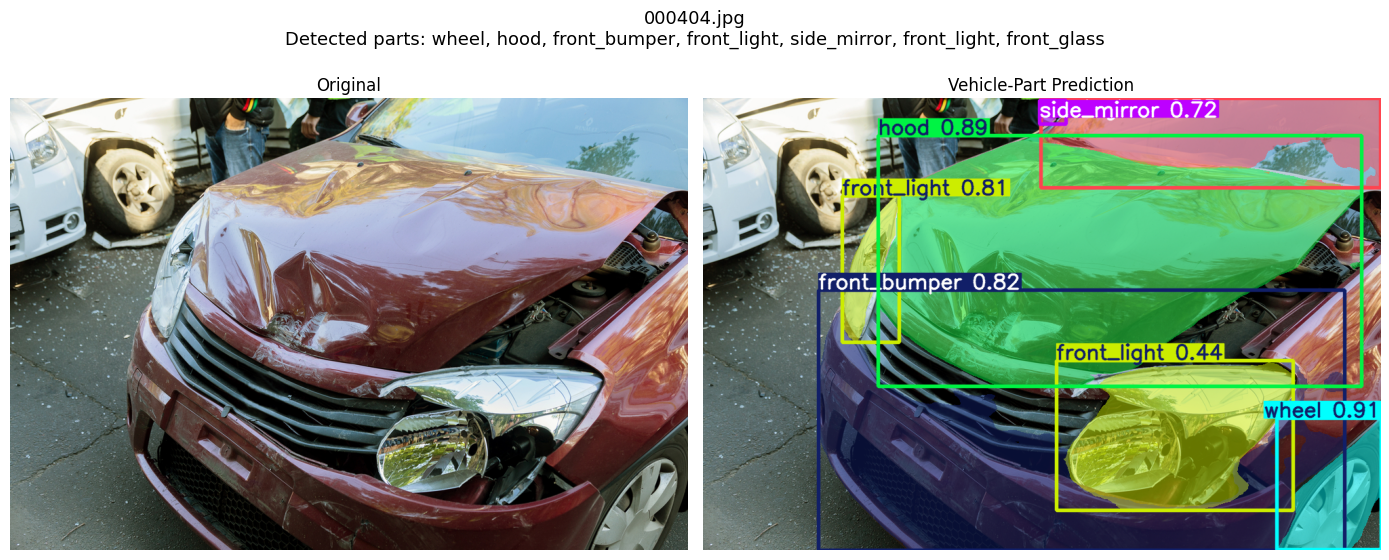

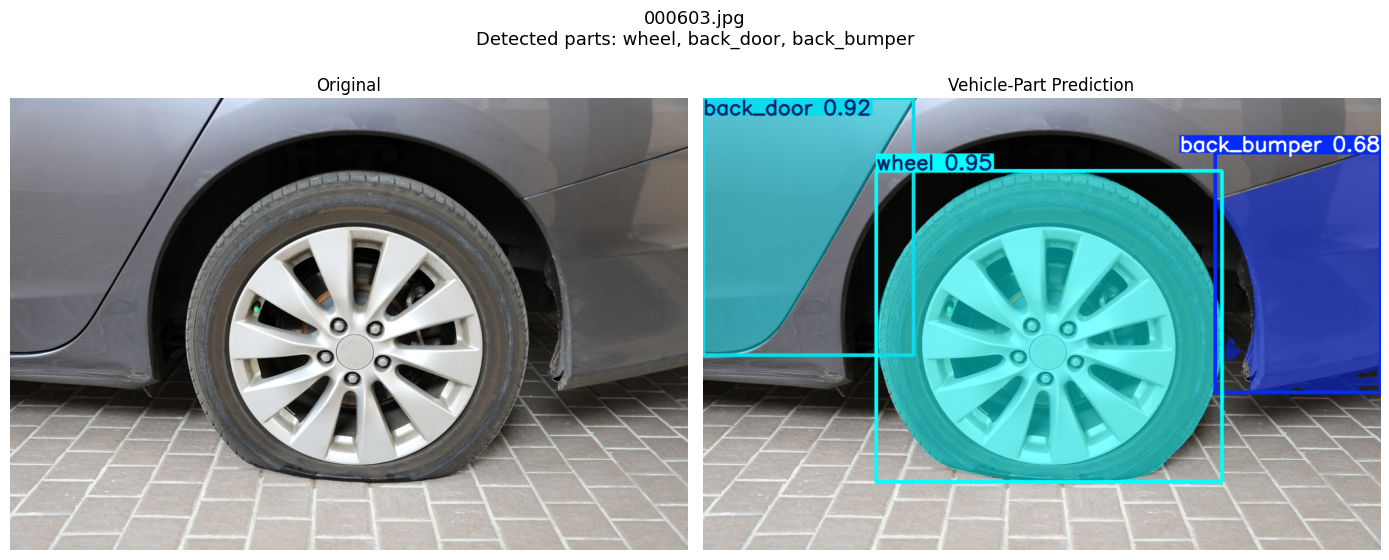

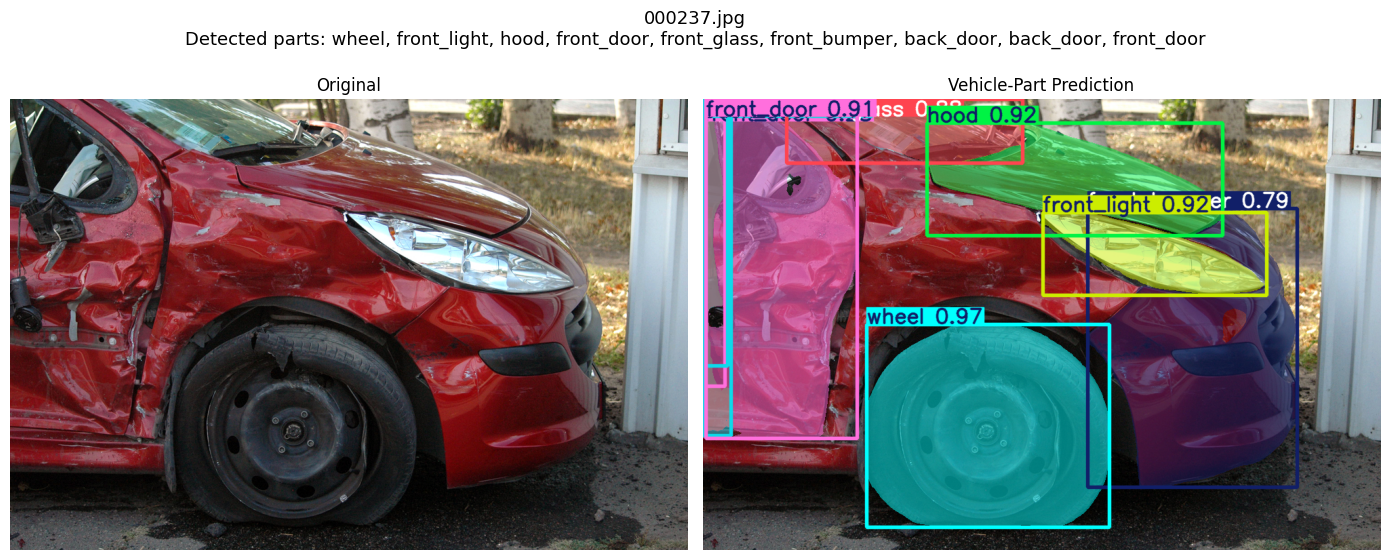

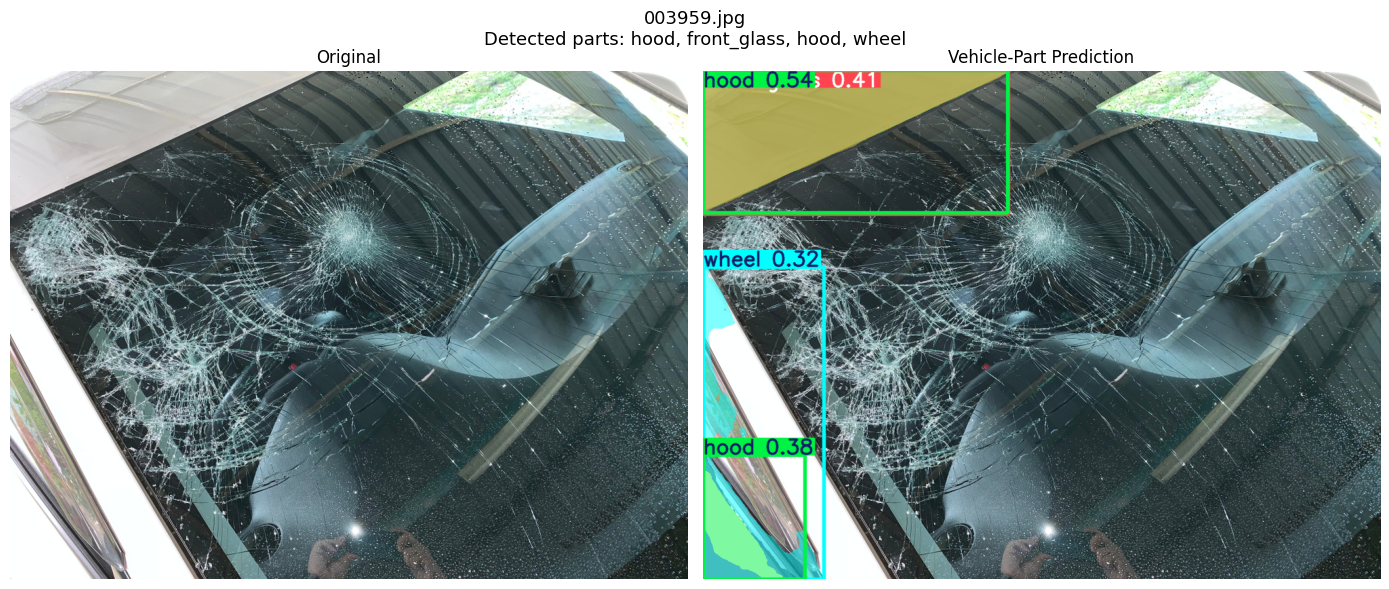

In [31]:
for image_path, result in zip(SELECTED_IMAGES, results):
    with Image.open(image_path) as image:
        original_image = image.convert("RGB")

    predicted_image = result.plot(
        labels=True,
        boxes=True,
        masks=True,
        conf=True,
    )[..., ::-1]

    detected_parts = []
    if result.boxes is not None:
        detected_parts = [
            result.names[int(class_id)]
            for class_id in result.boxes.cls.cpu().tolist()
        ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].imshow(original_image)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(predicted_image)
    axes[1].set_title("Vehicle-Part Prediction")
    axes[1].axis("off")

    plt.suptitle(
        f"{image_path.name}\nDetected parts: "
        f"{', '.join(detected_parts) if detected_parts else 'None'}",
        fontsize=13,
    )
    plt.tight_layout()
    plt.show()

## 9. Save the Prediction Images

In [32]:
for image_path, result in zip(SELECTED_IMAGES, results):
    save_path = OUTPUT_DIR / f"{image_path.stem}_prediction.jpg"
    result.save(filename=str(save_path))

print("Saved predictions to:", OUTPUT_DIR)
for saved_image in sorted(OUTPUT_DIR.glob("*_prediction.jpg")):
    print("-", saved_image.name)

Saved predictions to: /kaggle/working/cardd_part_visual_check
- 000204_prediction.jpg
- 000237_prediction.jpg
- 000404_prediction.jpg
- 000603_prediction.jpg
- 003959_prediction.jpg


## 10. Visual Review

The selected CarDD images were reviewed qualitatively because CarDD does not provide vehicle-part ground-truth masks compatible with this model.

The images were grouped by framing distance:

- **Full or wide view:** Most of the vehicle is visible.
- **Medium-distance view:** One vehicle side or several connected parts are visible.
- **Extreme close-up:** A single damaged region fills most of the image and little vehicle context remains.

For each image, the following points were checked:

1. Were the clearly visible vehicle parts detected?
2. Were any visible parts missed?
3. Were the predicted class names correct?
4. Did the segmentation masks follow the visible part boundaries?
5. Were there duplicate or overlapping predictions?
6. Were any nonexistent parts predicted?
7. Did severe damage or deformation affect the prediction?
8. Did cropping or loss of vehicle context affect the prediction?

### Important Taxonomy Limitation

Some visible regions cannot be evaluated as model errors because they are not included in the model's 13-class taxonomy.

For example, the model does not contain a `side_glass` class. Therefore, missing side-door glass is a taxonomy limitation rather than a failed prediction.

## 11. Findings and Decision

### 11.1 Main Findings

The vehicle-part model showed reasonable cross-domain performance on full and medium-distance damaged-car images.

Distinctive parts were generally the most reliable:

- Wheels were often detected with accurate masks.
- Front lights remained recognizable under substantial damage.
- The hood and bumpers were detected when sufficient vehicle structure was visible.
- The model could identify some doors despite visible deformation.

However, performance degraded on extreme close-up images where most of the vehicle context was outside the frame.

Observed failure cases included:

- False-positive wheel predictions near image boundaries.
- Incorrect hood or back-glass predictions.
- Low-confidence predictions for valid parts.
- Duplicate and overlapping front-door and back-door instances.
- Unstable boundaries when adjacent panels were severely deformed.
- Confusion between visually similar regions when the overall vehicle structure was not visible.

Increasing the confidence threshold may remove some low-confidence false positives. However, it would not solve all errors because some incorrect predictions had relatively high confidence.

### 11.2 Interpretation

The model appears to use both the visual appearance of each part and its spatial relationship to surrounding vehicle parts.

When the image contains a full or medium view, these spatial relationships help the model distinguish wheels, doors, lights, glass, and bumpers.

In extreme close-ups, the model loses this context. This creates a domain gap between the vehicle-part training data and the close-up damage images found in CarDD.

Therefore, the current model should not be considered universally reliable for identifying vehicle parts from isolated close-up images.

### 11.3 Project Decision

The current vehicle-part model will be used primarily with full or medium-distance vehicle images.

The proposed image-capture workflow is:

1. Capture a full or medium-distance image to identify the damaged vehicle part.
2. Capture a close-up image to analyze the damage type, area, and severity.
3. Combine the information from both views in the final assessment pipeline.

Retraining is not required for this feasibility check. If identifying parts directly from extreme close-up images becomes a project requirement, additional close-up training images with vehicle-part annotations will be needed.

### 11.4 Final Conclusion

The cross-domain feasibility check was partially successful.

The model generalized well enough to support preliminary vehicle-part localization when sufficient vehicle context was available. Its main limitation was extreme close-up imagery, especially when severe deformation removed the normal boundaries between adjacent parts.

These findings support a multi-view workflow rather than relying on a single close-up image for both part localization and damage assessment.

## Final Note

This is a qualitative cross-domain check. It does not replace quantitative evaluation on a future damaged-car dataset containing ground-truth vehicle-part masks.